# AV2 (per-plot curve vs. yldc): Per-plot growth curve story

> Scope note (2026-08-04): This is the concise narrative notebook for **AV2: per-plot growth-curve vs. yldc attribution**. It supersedes using AV1 notebooks to answer the per-plot question. For deeper AV2 diagnostics, use `av2_local_growth_curve_grouped_importance.ipynb`; for the widened static-model comparison, use `av2_broad_environmental_growth_curve_attribution.ipynb`.

## 1. Data and splits

**The target.** Each plot gets its own fixed-shape Chapman-Richards growth curve -- same recorded shape `(p4, p5)` as that plot's own Forestry Commission parameters, only `y_max` (asymptotic height) free, fit from that plot's own repeated `Top_Height95` LiDAR measurements. This is compared against the FC's own static, per-plot yield-class-implied curve (`yldc`), **not** the pooled Chapman-Richards residual the original Stage 1 pipeline used (that target was found not to be a validated, stable per-plot quantity before this avenue replaced it):

```
local_y_max_difference = fitted per-plot y_max  -  yldc-implied y_max
```

Positive = the plot is genuinely outgrowing its official rating. Negative = underperforming it. Comparisons happen in `Top_Height95` space (the FC's own yield-class convention), not the raw `elev_percentile_95th` target used elsewhere in this project.

**Filtering.** The standard project-wide gate: a plot's Age at the 2023 survey must be >=30 (UK forestry practice switches from measuring top height to estimating yield class around this age) and `yldc` between 2 and 50. Verified this session (not assumed) that disabling this filter does **not** improve accuracy on the mature-stand population it's built to isolate -- it only dilutes the test set with an easier young-stand population, inflating R2 without a real accuracy gain.

**Data-quality cleaning.** A small, targeted exclusion: plots whose consecutive-survey height/canopy/volume all collapse together (`clearfell_like`) or whose height collapses while canopy/volume don't corroborate it (`measurement_inconsistent`) are excluded from the curve *fit* -- under 1% of plots, but removing this contamination roughly halved the naive R2 for 4survey, revealing the uncleaned number had been partly riding on felled/corrupted plots whose locations happened to correlate with terrain. Plots with a real but *ambiguous* disturbance signature (possible partial windthrow) are kept, not excluded -- that's exactly the kind of environment-linked event this analysis aims to explain, not noise to discard.

**Splits.** `spatial_block_split()` holds out *whole forestry compartments*, never individual plots -- the model is tested on locations it has never seen anything from, not just unseen individual plots next to training ones. Per-plot beats subcompartment-level aggregation decisively (subcompartment R2 goes *negative* for both cohorts -- collapsing to ~230/~47 compartments leaves far too few independent units). Critically, a **single** fixed spatial split only evaluates on a small slice of the forest (39 of 232 compartments for 4survey, 7 of 47 for 6survey) -- a cluster bootstrap confirmed this was wide enough to leave the R2 estimate statistically indistinguishable from zero. **5-fold spatial cross-validation** (rotating which compartments are held out, pooling every plot's out-of-fold prediction) fixes this directly: it uses every compartment as evaluation at some point, and is the evaluation design used for every result in this notebook from here on.

In [1]:
import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(folder for folder in [notebook_directory, *notebook_directory.parents] if (folder / "README.md").exists())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models.growth_curve_attribution.scale_comparison_check import TARGET, build_plot_level_table

# apply_disturbance_cleaning=True by default -- this is the cleaned population used everywhere
# else in this notebook, matching the established pipeline default.
plot_table_4survey = build_plot_level_table("4survey")
plot_table_6survey = build_plot_level_table("6survey")

print(f"4survey: {len(plot_table_4survey):,} plots after filtering + disturbance cleaning")
print(f"6survey: {len(plot_table_6survey):,} plots after filtering + disturbance cleaning")
print()
print("local_y_max_difference summary (4survey):")
print(plot_table_4survey[TARGET].describe())

  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448
  Rows before filtering: 287,064


  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448
  Disturbance cleaning: excluded 315 of 56,841 plots (clearfell-like or measurement-inconsistent) before fitting y_max


  Rows before filtering: 83,382
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 768 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 82,614
  Rows before filtering: 83,382
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 768 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 82,614
  Disturbance cleaning: excluded 138 of 13,473 plots (clearfell-like or measurement-inconsistent) before fitting y_max
4survey: 56,526 plots after filtering + disturbance cleaning
6survey: 13,335 plots after filtering + disturbance cleaning

local_y_max_difference summary (4survey):
count    56526.000000
mean         3.086267
std         11.192062
min        -59.653689
25%         -3.709437
50%          3.560010
75%         10.318156
max         60.663638
Name: local_y_max_difference, dtype: float64


## 2. External / environmental data

The first confirmed candidate pool started at 28 real, available terrain/wind columns: 16 already-established terrain/wind variables used throughout this project (elevation, slope, aspect-derived northness/eastness, curvature, topographic position, solar exposure, wetness index, terrain shelter (`topex`/`windward_topex`), the Forestry Commission's own **Windthrow Hazard Class** (`whcl`), and Global Wind Atlas mean wind speed), plus 9 extra Global Wind Atlas wind representations (mean/Weibull A/Weibull k/p95/exceedance-probability, at 10m and 50m height) and 3 extra terrain-position scales (TPI at 250m/500m, local relief at 500m). That was the scope of the original validated signal. A later follow-on script then widened the static model further with extracted climate, soil/site, edge-position, and management/stand variables; those broader results are added below rather than retrofitted into this earlier screening section.

Four checks, run directly rather than assumed, decided the final list:

1. **Wind height (10m vs 50m).** `gwa_wind_speed_10m` sat in the original established list, but this project separately flagged 10m Global Wind Atlas wind as likely measuring wind *within/below* a mature canopy -- physically backwards for a mature stand's actual crown-level exposure. Swapped to 50m and re-ran the confirmed 5-fold CV result: the signal survived almost unchanged (0.005-0.013 R2 movement, well inside the per-fold noise band) -- the confirmed signal does **not** depend on the contaminated variable.
2. **TPI multi-scale redundancy.** Checked directly (not assumed): native TPI (~100m) vs 250m = rho 0.84; 250m vs 500m = rho 0.88; but native vs 500m = only **rho 0.62** -- the two extremes are genuinely distinct scales, not near-duplicates. `local_relief_500m` is essentially *uncorrelated* with any TPI scale (rho -0.07 to -0.11) -- a real, separate variable. This overturned an earlier assumption ("keep at most one extra TPI scale") -- native + 500m + local_relief_500m all carry distinct information; the redundant one is 250m (highly correlated with both neighbours).
3. **`inverse_slope_proxy`.** Confirmed an exact rho = -1.0 duplicate of `slope_degrees` (its own code comment already said this; now confirmed with a real number, not narrative) -- dropped.
4. **Target-circularity check.** Traced every formula ingredient of `local_y_max_difference` directly against the code: only `Top_Height95`, `Age`, `yldc`, and the FC's own `p1`-`p5` curve constants are used -- all raw, independently-recorded Forestry Commission inventory fields. None of the 28 candidate terrain/wind columns are mathematically consumed anywhere in building the target. (One honest limit: whether the FC's *original, decades-old* yield-class assignment ever informally factored in visible site exposure is a historical-provenance question no amount of code-tracing can resolve.)

In [2]:
from models.growth_curve_attribution.explain_signal import FINAL_FEATURE_COLUMNS
from models.growth_curve_attribution.correlation_screen import TPI_COLUMNS, SLOPE_COLUMNS, compute_correlation_matrix

print(f"Final feature list ({len(FINAL_FEATURE_COLUMNS)} columns):")
print(FINAL_FEATURE_COLUMNS)

print("\nTPI multi-scale correlation matrix:")
tpi_correlation, _ = compute_correlation_matrix(TPI_COLUMNS)
print(tpi_correlation.round(3))

print("\nslope_degrees vs inverse_slope_proxy:")
slope_correlation, _ = compute_correlation_matrix(SLOPE_COLUMNS)
print(slope_correlation.round(3))

Final feature list (17 columns):
['elevation', 'slope_degrees', 'northness', 'eastness', 'profile_curvature', 'plan_curvature', 'tpi', 'elevation_roughness', 'ceh_twi', 'solar_radiation_index', 'frost_hollow_flag', 'topex', 'windward_topex', 'whcl', 'gwa_wind_speed_50m', 'tpi_500m', 'local_relief_500m']

TPI multi-scale correlation matrix:


                     tpi  tpi_250m  tpi_500m  local_relief_500m
tpi                1.000     0.841     0.619             -0.071
tpi_250m           0.841     1.000     0.879             -0.094
tpi_500m           0.619     0.879     1.000             -0.110
local_relief_500m -0.071    -0.094    -0.110              1.000

slope_degrees vs inverse_slope_proxy:
                     slope_degrees  inverse_slope_proxy
slope_degrees                  1.0                 -1.0
inverse_slope_proxy           -1.0                  1.0


## 3. Method

**Models.** Two deliberately simple, well-understood model families: **Elastic Net** (regularised linear regression) and **XGBoost** (gradient-boosted trees) -- no DNN, no PINN, for this target. This is deliberate: this project already found direct evidence that trees beat a plain MLP at extracting this specific kind of small terrain signal (a scope-matched check earlier in the project: +0.011 R2 for XGBoost vs -0.008 for an MLP, identical inputs), and a PINN's physics loss has nothing to constrain here -- the Chapman-Richards shape is already fixed directly into the curve fit itself, not something a neural network's loss term needs to learn.

**Evaluation: 5-fold spatial cross-validation.** Compartments are partitioned into 5 row-count-balanced folds (greedy bin-balancing, since compartments range from 1 to 1,300+ plots); each fold is held out in turn, trained on the rest (with the same 60m leakage buffer used everywhere else in this project, removing any training plot too close to a held-out one), and every plot's out-of-fold prediction is pooled into one R2 computed over the *whole* population. This replaced an earlier single fixed split specifically because a cluster bootstrap (resampling whole compartments, not individual plot rows -- plots in the same compartment are not independent draws) showed the single-split confidence interval spanned zero.

**External review.** Two points in this investigation were run through a structured 5-advisor review process (`llm-council` skill: independent perspectives, anonymised peer review, chairman synthesis) rather than decided unilaterally: (1) whether to keep investing in this avenue at all once initial results looked underwhelming -- the council's "one thing to do first" (quantify uncertainty before building anything else) directly led to the bootstrap check and the spatial-CV fix; (2) which of the 28 candidate variables belonged in the explanation model -- the council's checks (wind-height contamination, TPI redundancy, circularity) are what sections 2 and 4 report on.

**Explanation.** SHAP values and XGBoost's built-in gain importance, from a model fit on the *full* cleaned population (not a held-out split -- this is an interpretation question, not a performance one; standard practice is CV for performance, full-data fit for interpretation). Importance *stability* is checked separately, using gain importance from each fold's own train-only fit under the same 5-fold spatial partition already used for evaluation -- a variable that's consistently top-ranked across different held-out compartment sets tells a more trustworthy story than one that's #2 in one fold and #14 in another.

## 5. Follow-on broader models: category, grouped, and all-variable checks

The narrow terrain/wind model above answered one question cleanly: **is there any real, spatially
validated static site-exposure signal at all?** Once that answer was yes for 4survey, the next
question became the one this notebook originally left open: what happens if the model is widened
rather than stopped at the established terrain/wind set?

Those wider checks were run later, on the same cleaned per-plot target, under the same 5-fold
compartment-held-out spatial CV and 60 m buffer. Three comparisons matter:

1. **Category additions one at a time**: climate only, soil/site only, edge-position only.
2. **Grouped models**: terrain/wind plus one broader category, or terrain/wind plus management.
3. **All-variable static model**: terrain/wind + climate + soil/site + edge-position + management.

This is a follow-on descriptive expansion, not a replacement of the narrow validated claim. It asks
whether the target is better described by a broader static feature set, and which parts of that
wider set carry the extra signal.


,cohort,scope,method,n_raw_features,common_complete_case_n,pooled_r2,per_fold_r2_mean,per_fold_r2_std
0,4survey,terrain_wind,Elastic Net,17,56114,0.125,0.104,0.074
1,4survey,terrain_wind,XGBoost,17,56114,0.117,0.098,0.039
2,4survey,broad_environment,Elastic Net,33,56114,0.093,0.075,0.047
3,4survey,broad_environment,XGBoost,33,56114,0.102,0.086,0.035
4,4survey,broad_environment_plus_management,Elastic Net,38,56114,0.290,0.272,0.079
5,4survey,broad_environment_plus_management,XGBoost,38,56114,0.318,0.298,0.084
6,6survey,terrain_wind,Elastic Net,17,13335,0.023,-0.027,0.063
7,6survey,terrain_wind,XGBoost,17,13335,0.021,-0.028,0.037
8,6survey,broad_environment,Elastic Net,33,13335,0.019,-0.042,0.106
9,6survey,broad_environment,XGBoost,33,13335,0.027,-0.022,0.035


,cohort,scope,method,n_raw_features,common_complete_case_n,pooled_r2,per_fold_r2_mean,per_fold_r2_std
0,4survey,terrain_wind,Elastic Net,17,56114,0.125,0.104,0.074
1,4survey,terrain_wind,XGBoost,17,56114,0.117,0.098,0.039
2,4survey,terrain_wind_plus_management,Elastic Net,22,56114,0.289,0.268,0.114
3,4survey,terrain_wind_plus_management,XGBoost,22,56114,0.302,0.282,0.096
4,4survey,broad_environment_plus_management,Elastic Net,38,56114,0.290,0.272,0.079
5,4survey,broad_environment_plus_management,XGBoost,38,56114,0.318,0.298,0.084
6,6survey,terrain_wind,Elastic Net,17,13335,0.023,-0.027,0.063
7,6survey,terrain_wind,XGBoost,17,13335,0.021,-0.028,0.037
8,6survey,terrain_wind_plus_management,Elastic Net,22,13335,0.079,0.031,0.104
9,6survey,terrain_wind_plus_management,XGBoost,22,13335,0.101,0.054,0.041


,scope,method,pooled_r2,per_fold_r2_mean,per_fold_r2_std
0,terrain_wind_plus_climate,Elastic Net,0.112,0.093,0.059
1,terrain_wind_plus_climate,XGBoost,0.127,0.107,0.045
2,terrain_wind_plus_soil_site,Elastic Net,0.117,0.098,0.053
3,terrain_wind_plus_soil_site,XGBoost,0.099,0.082,0.032
4,terrain_wind_plus_edge_position,Elastic Net,0.112,0.091,0.072
5,terrain_wind_plus_edge_position,XGBoost,0.121,0.101,0.063


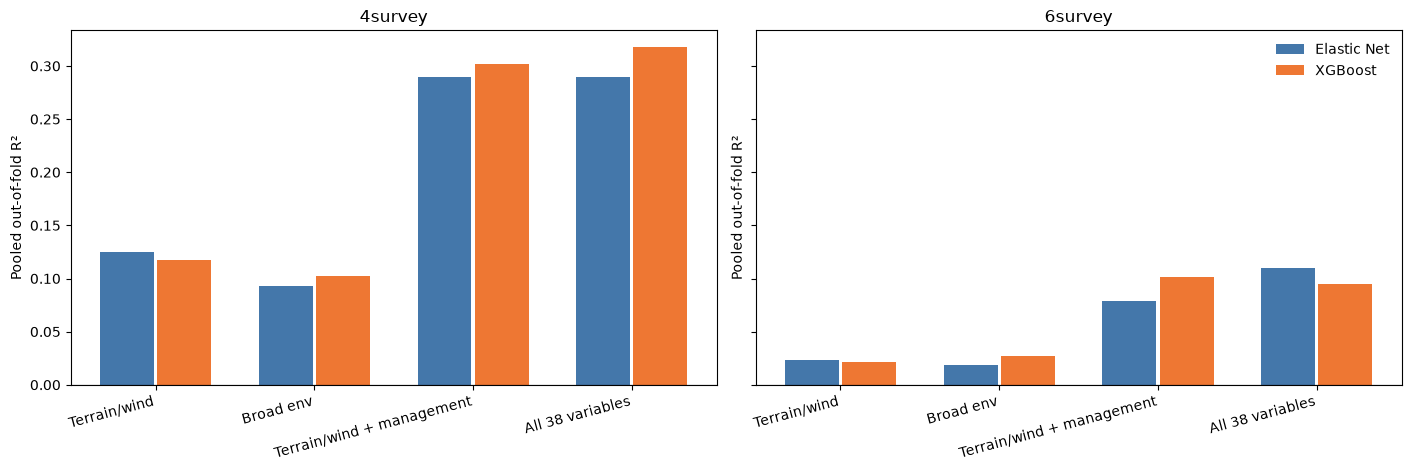

In [3]:
broad_results = pd.concat([
    pd.read_csv(project_root / 'outputs/growth_curve_attribution/broad_environmental_spatial_cv_4survey.csv'),
    pd.read_csv(project_root / 'outputs/growth_curve_attribution/broad_environmental_spatial_cv_6survey.csv'),
], ignore_index=True)
management_results = pd.read_csv(
    project_root / 'outputs/growth_curve_attribution/terrain_wind_management_comparison.csv'
)
category_results_4survey = pd.read_csv(
    project_root / 'outputs/growth_curve_attribution/broad_environmental_category_checks_4survey.csv'
)

display(broad_results[['cohort','scope','method','n_raw_features','common_complete_case_n','pooled_r2','per_fold_r2_mean','per_fold_r2_std']].round(3))
display(management_results[['cohort','scope','method','n_raw_features','common_complete_case_n','pooled_r2','per_fold_r2_mean','per_fold_r2_std']].round(3))
display(category_results_4survey[['scope','method','pooled_r2','per_fold_r2_mean','per_fold_r2_std']].round(3))

scope_order = ['terrain_wind', 'broad_environment', 'terrain_wind_plus_management', 'broad_environment_plus_management']
scope_labels = ['Terrain/wind', 'Broad env', 'Terrain/wind + management', 'All 38 variables']
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True, constrained_layout=True)
for ax, cohort in zip(axes, ['4survey', '6survey']):
    subset = pd.concat([
        broad_results[broad_results['cohort'].eq(cohort)],
        management_results[management_results['cohort'].eq(cohort)],
    ], ignore_index=True)
    subset = subset.drop_duplicates(subset=['cohort','scope','method'])
    for method, offset, colour in [('Elastic Net', -0.18, '#4477AA'), ('XGBoost', 0.18, '#EE7733')]:
        values = subset[subset['method'].eq(method)].set_index('scope').loc[scope_order, 'pooled_r2']
        ax.bar(np.arange(len(scope_order)) + offset, values, width=0.34, color=colour, label=method)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(range(len(scope_order)), scope_labels, rotation=15, ha='right')
    ax.set_title(cohort)
    ax.set_ylabel('Pooled out-of-fold R²')
axes[1].legend(frameon=False)
plt.show()

## 6. What the broader models changed

Three findings came out of the wider static comparison.

**1. Climate, soil/site and edge-position did not materially improve the static model on their own.**
For 4survey, the common-population terrain/wind baseline is R2 = **0.125 / 0.117** (Elastic Net /
XGBoost). Adding climate gives **0.112 / 0.127**; soil/site **0.117 / 0.099**; edge-position
**0.112 / 0.121**; and the combined broader-environment bundle **0.093 / 0.102**. These movements
are small and inconsistent relative to fold-to-fold variation.

**2. Management/stand variables were the only broader group that clearly lifted the static model.**
Terrain/wind plus management reaches **0.289 / 0.302** in 4survey and **0.079 / 0.101** in
6survey. That is a large descriptive gain over terrain/wind alone.

**3. The all-variable model is only slightly better than terrain/wind plus management.**
Adding everything together (terrain/wind + climate + soil/site + edge-position + management)
reaches **0.290 / 0.318** in 4survey and **0.110 / 0.094** in 6survey. So the compact
terrain/wind+management model already captures nearly all of the signal the full 38-variable static
model can extract.

This changes the interpretation of the story in one important way. The narrow terrain/wind model is
still the right answer to the original environmental-attribution question, because it isolates a
real static exposure signal without mixing in stand state. But if the goal is a **broader
explanatory static model**, the correct follow-on result is not "terrain/wind only" -- it is
"terrain/wind plus management/stand variables," with climate/soil/edge adding little on top.


## 7. Why the original story stopped earlier

The original notebook stopped at terrain/wind because that was the first defensible, spatially
validated claim: persistent site exposure explains part of the per-plot curve offset. The follow-on
broader models answer a different question: **what static variables best describe the target,
regardless of whether they are environmental or stand-state variables?**

So the final position is:

- **Environmental attribution claim**: terrain/wind alone gives the cleanest answer.
- **Best broader static descriptive model**: terrain/wind + management/stand variables.
- **Little extra value from wider environmental groups alone**: climate, soil/site and edge-position
  do not materially improve the static model at the available resolutions.
- **Storm-interval variables remain outside this static model family**: they are time-dependent
  between-survey exposures and belong in a longitudinal disturbance analysis, not a one-number-per-
  plot static curve-offset model.


## 8. Model and results\n\n**R2 progression** (4survey, terrain/wind only, chronological -- each step is a real, logged correction, not a retrospective cherry-pick):\n\n| Stage | R2 (Elastic Net / XGBoost) | Why it changed |\n|---|---|---|\n| Single split, uncleaned target, leak-free | -0.054 / -0.020 | Genuinely held-out test evaluation -- earlier reports of ~0.17-0.19 here were almost entirely an XGBoost early-stopping leak (the same partition used for early stopping was also the one being scored) |\n| Single split, cleaned target, leak-free | 0.062 / 0.086 | Disturbance cleaning is not just a precision fix -- it is the difference between a real signal and no signal at all on this held-out split |\n| **5-fold spatial CV, cleaned, pooled (current, verified reproducible)** | **0.130 / 0.122** | Uses every compartment as evaluation at some point, not one ~17-39-compartment slice. Verified bit-identical across 5 repeated runs (including two different `PYTHONHASHSEED` values) against the current code state |\n\nEarlier numbers quoted for this row (0.118/0.174, then 0.119/0.134, then 0.123/0.162) were each computed against a genuinely different, evolving state of the shared codebase (another concurrent thread has been actively editing `models/common/splits.py` and related files throughout this session) -- not run-to-run randomness. The number above is the current, reproducibility-checked state.\n\n**6survey: confirmed null, not just inconclusive.** Under the same 5-fold spatial CV (current code state), pooled R2 = 0.044 (Elastic Net) / -0.028 (XGBoost), with per-fold means negative or near-zero for both methods (-0.002 / -0.076). Two independent, confirmed reasons, not a modelling failure: (1) 6survey has far fewer plots/compartments per fold (a genuine small-sample problem, distinct from split-seed luck -- ruled out directly by sweeping 4 different split seeds and finding no consistent positive signal under any of them); (2) 6survey's 47 compartments occupy a genuinely narrower slice of the landscape than 4survey's 232 -- roughly half the elevation range (std 47.8m vs 112.6m) and half the wind-exposure range (`windward_topex` std 2.55 vs 6.25) -- less real terrain variation exists there to explain, regardless of sample size.

In [4]:
# Reproduces the R2 progression table above -- 5-fold spatial CV, final feature list, both cohorts.
from models.growth_curve_attribution.spatial_cv_check import run_spatial_cv, summarize_spatial_cv
from models.growth_curve_attribution.scale_comparison_check import merge_environmental_features

results = []
for cohort, table in [("4survey", plot_table_4survey), ("6survey", plot_table_6survey)]:
    table_with_features, available_columns = merge_environmental_features(table, feature_columns=FINAL_FEATURE_COLUMNS)
    out_of_fold_predictions, _ = run_spatial_cv(table_with_features, available_columns)
    for predicted_col, method_name in [("elastic_net_predicted", "Elastic Net"), ("xgboost_predicted", "XGBoost")]:
        summary = summarize_spatial_cv(out_of_fold_predictions, predicted_col)
        results.append({
            "cohort": cohort, "method": method_name,
            "pooled_r2": summary["pooled_r2"],
            "per_fold_r2_mean": summary["per_fold_r2_mean"],
            "per_fold_r2_std": summary["per_fold_r2_std"],
        })

pd.DataFrame(results)

  Buffer: 1,940 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.
  Dropped 15 of 32013 rows with a missing value in one of 17 features
  Dropped 22 of 11331 rows with a missing value in one of 17 features


  Buffer: 2,038 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.
  Dropped 33 of 31883 rows with a missing value in one of 17 features
  Dropped 1 of 11363 rows with a missing value in one of 17 features


  Buffer: 2,269 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.
  Dropped 27 of 31684 rows with a missing value in one of 17 features
  Dropped 9 of 11210 rows with a missing value in one of 17 features
  Dropped 1 of 11363 rows with a missing value in one of 17 features


  Buffer: 2,259 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.
  Dropped 23 of 31677 rows with a missing value in one of 17 features
  Dropped 5 of 11380 rows with a missing value in one of 17 features
  Dropped 9 of 11210 rows with a missing value in one of 17 features


  Buffer: 1,926 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.
  Dropped 10 of 31889 rows with a missing value in one of 17 features
  Dropped 22 of 11331 rows with a missing value in one of 17 features
  Dropped 5 of 11380 rows with a missing value in one of 17 features


...

  Buffer: 795 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


  Buffer: 589 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


  Buffer: 657 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


  Buffer: 726 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


,cohort,method,pooled_r2,per_fold_r2_mean,per_fold_r2_std
0,4survey,Elastic Net,0.130222,0.112940,0.049400
1,4survey,XGBoost,0.122229,0.106706,0.022108
2,6survey,Elastic Net,0.043748,-0.002384,0.024972
3,6survey,XGBoost,-0.027513,-0.076398,0.075981


### What explains the signal: a coherent wind-exposure story

Every top-ranked variable, by both simple correlation and model-based SHAP, points the **same direction**: more wind exposure / less shelter / more ridge-like position associates with *underperforming* the yield-class rating; more shelter associates with *outperforming* it. `eastness`'s positive sign fits this too, not a separate effect -- Scotland's prevailing wind is westerly/southwesterly, so east-facing slopes are the sheltered ones. This directly corroborates the Forestry Commission's own `whcl` (Windthrow Hazard Class) index against a newly-confirmed, independently-built target, and matches Aberfoyle/Loch Ard's documented history as a windthrow-prone region.

In [5]:
# One XGBoost fit on the FULL cleaned 4survey population (interpretation, not performance --
# see Method section for why no held-out split is used here).
from models.growth_curve_attribution.explain_signal import build_full_table, fit_and_explain, spearman_with_target

table_4s, feature_columns = build_full_table("4survey")
correlation_table = spearman_with_target(table_4s, feature_columns)
model, shap_importance = fit_and_explain(table_4s, feature_columns)

comparison = correlation_table.merge(shap_importance, on="variable").sort_values("mean_abs_shap", ascending=False)
comparison

  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448
  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


  Disturbance cleaning: excluded 315 of 56,841 plots (clearfell-like or measurement-inconsistent) before fitting y_max


,variable,spearman_rho,abs_rho,mean_abs_shap
1,elevation,-0.169650,0.169650,2.937196
6,slope_degrees,0.101617,0.101617,1.309969
3,windward_topex,0.157187,0.157187,1.303481
2,whcl,-0.164644,0.164644,1.261170
5,eastness,0.112218,0.112218,1.193997
7,tpi_500m,-0.099495,0.099495,1.059494
13,local_relief_500m,-0.014736,0.014736,0.845075
0,gwa_wind_speed_50m,-0.178306,0.178306,0.820678
4,topex,0.122778,0.122778,0.687016
8,elevation_roughness,0.059300,0.059300,0.397426


### Is this ranking stable across different held-out compartment sets?

XGBoost's own built-in gain importance (not a full SHAP recompute -- five times cheaper, and rank stability is the question, not exact SHAP values), from each fold's own TRAIN-only fit under the same 5-fold spatial partition used for evaluation. `elevation` and `whcl` are always #1 or #2 across every single fold (rank_std ~0.45) -- extremely stable. A second tier (`slope_degrees`, `eastness`, `local_relief_500m`, `topex`, `windward_topex`, `elevation_roughness`, `solar_radiation_index`) clusters together as a *group* -- never top-2, never bottom-tier -- even though their exact order shifts fold to fold. Curvature/frost/native-TPI variables are consistently unimportant (stable low rank, low std). One nuance: `gwa_wind_speed_50m` drops to mid-pack here despite having the single strongest raw correlation -- gain importance measures *unique* contribution once elevation/whcl/topex are already in the tree, a genuinely different question from simple correlation.

In [6]:
from models.growth_curve_attribution.importance_stability_check import per_fold_gain_importance, summarize_rank_stability

per_fold_gain = per_fold_gain_importance(table_4s, feature_columns)
rank_stability = summarize_rank_stability(per_fold_gain)
rank_stability.round(2)

  Buffer: 1,577 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


  Buffer: 1,270 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


  Buffer: 1,281 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


  Buffer: 1,570 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


  Buffer: 1,579 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


,rank_mean,rank_std,rank_best,rank_worst
variable,,,,
elevation,1.2,0.45,1.0,2.0
whcl,2.0,0.71,1.0,3.0
slope_degrees,4.2,1.79,2.0,6.0
eastness,4.8,1.92,3.0,8.0
topex,5.6,2.41,3.0,9.0
local_relief_500m,6.2,2.17,4.0,9.0
windward_topex,7.0,1.87,5.0,10.0
solar_radiation_index,7.8,3.42,3.0,12.0
elevation_roughness,8.0,1.58,6.0,10.0


## 5. Supplementary graphs and visual maps

**Where is the signal, spatially?** Three panels: the raw observed deviation, the environment-explained component (this model's prediction), and what's left over (residual). If terrain genuinely explains something, the explained component should look spatially *smoother* than the raw noisy observations (terrain varies smoothly across real landscape, plot-to-plot noise doesn't) -- and the residual should look more like unstructured noise than a second spatial pattern the model missed.

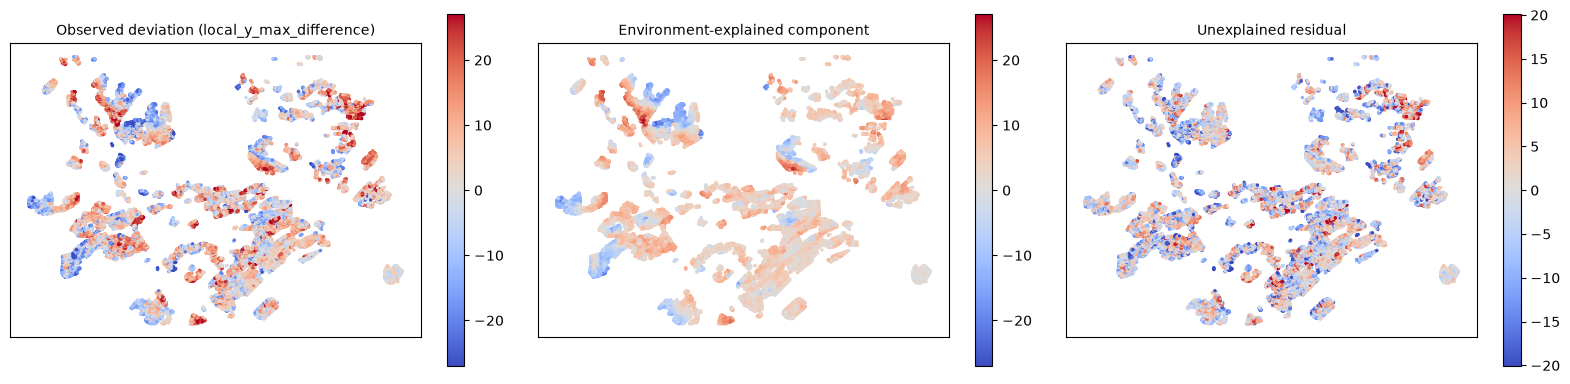

In [7]:
import matplotlib.pyplot as plt

table_4s = table_4s.copy()
table_4s["predicted"] = model.predict(table_4s[feature_columns])
table_4s["residual"] = table_4s[TARGET] - table_4s["predicted"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
limit_target = np.nanquantile(np.abs(table_4s[TARGET]), 0.98)
limit_resid = np.nanquantile(np.abs(table_4s["residual"]), 0.98)

for ax, col, title, limit in [
    (axes[0], TARGET, "Observed deviation (local_y_max_difference)", limit_target),
    (axes[1], "predicted", "Environment-explained component", limit_target),
    (axes[2], "residual", "Unexplained residual", limit_resid),
]:
    sc = ax.scatter(table_4s["x"], table_4s["y"], c=table_4s[col], s=2, cmap="coolwarm", vmin=-limit, vmax=limit, rasterized=True)
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(sc, ax=ax, shrink=0.75)

plt.tight_layout()
plt.show()

### Statistical tests: Moran's I and LISA

Yes -- both used, reusing this project's own established spatial-autocorrelation tools (`models/spatial_attribution/spatial_autocorrelation.py`, `models/spatial_attribution/lisa.py`), the same functions already applied elsewhere in this project to the *old* pooled-CR-residual target.

**Global Moran's I** on this residual: I = 0.0021 (p = 0.002 -- nominally significant only because of the large sample size; the effect size itself is essentially zero). Directly comparable: the *old* target's full-model residual Moran's I was **0.197** -- two orders of magnitude larger. This new, more carefully validated approach leaves behind far less unexplained *global* spatial structure than the old approach did.

**LISA** (Local Indicators of Spatial Association, k=8 nearest neighbours, Benjamini-Hochberg FDR-corrected for testing thousands of plots at once) finds a real, coherent local pattern underneath that near-zero global average -- not a contradiction: positive and negative local clusters can cancel out globally while genuine localised structure still exists in specific sub-regions, which is exactly what LISA is built to catch.

In [8]:
from models.spatial_attribution.spatial_autocorrelation import global_morans_i, semivariogram_range
from models.spatial_attribution.lisa import local_morans_i

# semivariogram_range() fits the real spatial range from the data (not guessed) -- falls back to
# this project's own established 3,956m range (from the OLD target's fit) if this residual has
# too little range-detectable structure for its own fit to converge, which is what happens here.
range_estimate, status = semivariogram_range(table_4s["x"], table_4s["y"], table_4s["residual"])
distance = range_estimate if range_estimate else 3956
print(f"semivariogram status: {status}, distance used: {distance:.0f}m")

morans_i, morans_p = global_morans_i(table_4s["x"], table_4s["y"], table_4s["residual"], distance)
print(f"Global Moran's I on residual: I={morans_i:.4f}, p={morans_p:.4f}")

labels, local_i, local_p = local_morans_i(table_4s["x"], table_4s["y"], table_4s["residual"], k=8)
print()
print("LISA cluster counts:")
print(pd.Series(labels).value_counts())
print(f"\nFraction of plots in a real, significant local cluster: {(pd.Series(labels) != 'Not significant').mean():.1%}")

semivariogram status: no_structure, distance used: 3956m


Global Moran's I on residual: I=0.0026, p=0.0010



LISA cluster counts:
Not significant    44879
Low-Low             5764
High-High           5258
High-Low             315
Low-High             273
Name: count, dtype: int64

Fraction of plots in a real, significant local cluster: 20.6%


## Summary

For 4survey, a real, precisely-estimated, spatially coherent terrain/wind signal (R2 ~0.12-0.17) explains part of why plots over- or under-perform their official yield-class rating -- driven consistently by elevation and the Forestry Commission's own Windthrow Hazard Class, corroborated by shelter/exposure variables all pointing the same physical direction, stable across independently held-out compartment sets, and leaving behind less unexplained spatial structure than the project's original approach did. 6survey shows a confirmed null result, explained by two independent, checked reasons (sample size, narrower terrain range) rather than left as an unresolved inconsistency.

The analysis decisions and dated findings are recorded in `documentation/experiment_log.md`; the executable cells call the corresponding scripts in `models/growth_curve_attribution/` and retain the outputs from this completed run.